# Polity assignment
Describes how individuals are assigned to Cliopatria polities and maps their activity per polity and century.

In [1]:
import json
import random
import tempfile

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch, Polygon
from shapely.geometry import box, shape
from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_enriched_v3.duckdb'
BASEMAP_PATH = '../data/ne_110m_admin_0_countries.geojson'

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

CENTURY_SNAPSHOTS = [-400, 500, 1400, 1900]

apply_style()

## External data — Natural Earth basemap

In [2]:
basemap = gpd.read_file(BASEMAP_PATH)
print('basemap countries:', len(basemap))

basemap countries: 177


## Load data
### Polity matches

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

con.sql("""
    CREATE TEMP TABLE matches AS
    SELECT entity.qid                   AS qid,
           match.polity.cliopatria_id   AS polity_id,
           match.polity.name            AS polity_name,
           match.years_spent_in_polity  AS years_spent_in_polity,
           match.assignation_method     AS assignation_method,
           peak_productivity.start_year AS peak_start,
           peak_productivity.end_year   AS peak_end
    FROM   individual_enriched, unnest(polity) AS unnested(match)
""")

method_counts = con.sql("""
    SELECT   assignation_method,
             COUNT(*)            AS n_matches,
             COUNT(DISTINCT qid) AS n_individuals
    FROM     matches
    GROUP BY assignation_method
""").pl()

methods_per_individual = con.sql("""
    SELECT   COUNT(DISTINCT assignation_method) AS n_methods
    FROM     matches
    GROUP BY qid
    ORDER BY n_methods DESC
    LIMIT    1
""").fetchone()[0]
assert methods_per_individual == 1, 'each individual is matched by a single method'
print('methods per individual (max):', methods_per_individual)
method_counts

methods per individual (max): 1


assignation_method,n_matches,n_individuals
str,i64,i64
"""polygon_of_birthplace""",1009884,709684
"""url_of_country_of_citizenship""",3226081,3181006
"""url_of_birthplace""",432,427
"""url_of_deathplace""",319,304
"""polygon_of_country_of_citizenship""",577427,444084
"""polygon_of_deathplace""",1364690,814694


### Denominators

In [4]:
denominators = con.sql("""
    SELECT COUNT(*)                              AS n_individuals,
           COUNT(individual_enriched.peak_productivity.start_year) AS n_dated,
           COUNT(*) FILTER (
               WHERE individual_enriched.peak_productivity.start_year IS NOT NULL
                 AND (individual.place_of_birth IS NOT NULL
                      OR individual.place_of_death IS NOT NULL
                      OR len(individual.country_of_citizenship) > 0)
           )                                     AS n_dated_and_located,
           COUNT(*) FILTER (WHERE len(individual_enriched.polity) > 0) AS n_matched
    FROM   individual_enriched
    JOIN   individual ON individual.entity.qid = individual_enriched.entity.qid
""").pl().row(0, named=True)

n_individuals, n_dated = denominators['n_individuals'], denominators['n_dated']
assert denominators['n_matched'] == method_counts['n_individuals'].sum()
for key, value in denominators.items():
    print(f'{key:22s}: {value:,}')

n_individuals         : 13,002,897
n_dated               : 9,823,124
n_dated_and_located   : 5,233,048
n_matched             : 5,150,199


### Active individuals per polity and century

In [5]:
con.sql("CREATE TEMP TABLE centuries AS SELECT unnest($centuries) AS century",
        params={'centuries': CENTURY_SNAPSHOTS})

century_counts = con.sql("""
    SELECT   centuries.century                              AS century,
             matches.polity_id                            AS polity_id,
             matches.polity_name                          AS polity_name,
             COUNT(*)                               AS n_all
    FROM     matches
    JOIN     centuries ON matches.peak_start <= centuries.century + 99 AND matches.peak_end >= centuries.century
    GROUP BY centuries.century, matches.polity_id, matches.polity_name
""").pl()

assert century_counts.select('century', 'polity_id').is_duplicated().sum() == 0
print('shape:', century_counts.shape)
century_counts.sort('n_all', descending=True).head()

shape: (1926, 4)


century,polity_id,polity_name,n_all
i32,i64,str,i64
1900,1148,"""United States of America""",465417
1900,1389,"""Union of Soviet Socialist Republics""",284950
1900,1412,"""Nazi Germany""",201316
1900,1102,"""Kingdom of Great Britain""",183629
1900,1467,"""French Fifth Republic""",160012


### Polygon per polity and century

In [6]:
con.sql("""
    CREATE TEMP TABLE territories AS
    SELECT cliopatria_id        AS polity_id,
           name                 AS polity_name,
           territory.start_year AS start_year,
           territory.end_year   AS end_year,
           territory.geometry   AS geometry
    FROM   polity, unnest(territories) AS unnested(territory)
""")

polygons = con.sql("""
    SELECT  centuries.century, territories.polity_id, territories.polity_name, territories.start_year, territories.end_year, territories.geometry
    FROM    territories
    JOIN    centuries ON territories.start_year <= centuries.century + 99 AND territories.end_year >= centuries.century
    QUALIFY row_number() OVER (
                PARTITION BY centuries.century, territories.polity_id
                ORDER BY abs((territories.start_year + territories.end_year) / 2.0 - (centuries.century + 50)), territories.start_year
            ) = 1
""").pl()

con.close()

assert polygons.select('century', 'polity_id').is_duplicated().sum() == 0
print('shape:', polygons.shape)
print(polygons.group_by('century').len().sort('century'))
polygons.drop('geometry').head()

shape: (760, 6)
shape: (4, 2)
┌─────────┬─────┐
│ century ┆ len │
│ ---     ┆ --- │
│ i32     ┆ u32 │
╞═════════╪═════╡
│ -400    ┆ 58  │
│ 500     ┆ 112 │
│ 1400    ┆ 240 │
│ 1900    ┆ 350 │
└─────────┴─────┘


century,polity_id,polity_name,start_year,end_year
i32,i64,str,i64,i64
-400,55,"""Zheng""",-383,-367
-400,67,"""Scythia""",-404,-351
-400,91,"""Achaemenid Empire""",-350,-338
-400,110,"""Qataban""",-350,-111
-400,118,"""Athenian Coalition""",-323,-319


## Preprocessing
### Linkage cascade

In [7]:
CASCADE_ORDER = [
    ('polygon_of_deathplace',             'Polygon merging', 'Place of death'),
    ('polygon_of_birthplace',             'Polygon merging', 'Place of birth'),
    ('polygon_of_country_of_citizenship', 'Polygon merging', 'Country of citizenship'),
    ('url_of_country_of_citizenship',     'URL matching',    'Country of citizenship'),
    ('url_of_deathplace',                 'URL matching',    'Place of death'),
    ('url_of_birthplace',                 'URL matching',    'Place of birth'),
]

cascade = (
    pl.DataFrame(CASCADE_ORDER, schema=['assignation_method', 'method', 'origin'], orient='row')
    .with_row_index('step', offset=1)
    .join(method_counts, on='assignation_method', how='left')
    .with_columns(pl.col('n_matches', 'n_individuals').fill_null(0))
    .with_columns((pl.col('n_matches') / pl.col('n_matches').sum() * 100).round(1).alias('pct_of_matches'))
)

assert cascade['n_individuals'].sum() == denominators['n_matched']
print(f'{cascade["n_matches"].sum():,} (individual, polity) matches for {denominators["n_matched"]:,} individuals')
cascade.select('step', 'method', 'origin', 'n_matches', 'pct_of_matches', 'n_individuals')

6,178,833 (individual, polity) matches for 5,150,199 individuals


step,method,origin,n_matches,pct_of_matches,n_individuals
u32,str,str,i64,f64,i64
1,"""Polygon merging""","""Place of death""",1364690,22.1,814694
2,"""Polygon merging""","""Place of birth""",1009884,16.3,709684
3,"""Polygon merging""","""Country of citizenship""",577427,9.3,444084
4,"""URL matching""","""Country of citizenship""",3226081,52.2,3181006
5,"""URL matching""","""Place of death""",319,0.0,304
6,"""URL matching""","""Place of birth""",432,0.0,427


### Individual-to-polity matching breakdown

In [8]:
coverage = (
    cascade
    .with_columns(
        (pl.col('n_individuals') / n_dated * 100).alias('share_of_dated_pct'),
        (pl.col('n_individuals') / n_individuals * 100).alias('share_of_total_pct'),
    )
    .with_columns(
        pl.col('share_of_dated_pct').cum_sum().alias('cumulative_dated_pct'),
        pl.col('share_of_total_pct').cum_sum().alias('cumulative_total_pct'),
    )
    .with_columns(pl.col('^.*_pct$').round(2))
)
coverage.select('step', 'method', 'origin', 'n_individuals', 'share_of_dated_pct',
                'cumulative_dated_pct', 'share_of_total_pct', 'cumulative_total_pct')

step,method,origin,n_individuals,share_of_dated_pct,cumulative_dated_pct,share_of_total_pct,cumulative_total_pct
u32,str,str,i64,f64,f64,f64,f64
1,"""Polygon merging""","""Place of death""",814694,8.29,8.29,6.27,6.27
2,"""Polygon merging""","""Place of birth""",709684,7.22,15.52,5.46,11.72
3,"""Polygon merging""","""Country of citizenship""",444084,4.52,20.04,3.42,15.14
4,"""URL matching""","""Country of citizenship""",3181006,32.38,52.42,24.46,39.6
5,"""URL matching""","""Place of death""",304,0.0,52.42,0.0,39.6
6,"""URL matching""","""Place of birth""",427,0.0,52.43,0.0,39.61


In [9]:
def century_frame(century, count_column):
    """Polities active in the century, with count and representative geometry."""
    counts = century_counts.filter((pl.col('century') == century) & (pl.col(count_column) > 0))
    joined = counts.join(polygons.filter(pl.col('century') == century).select('polity_id', 'geometry'),
                         on='polity_id', how='inner')
    return gpd.GeoDataFrame({'name': joined['polity_name'].to_list(),
                             'count': joined[count_column].to_list()},
                            geometry=[shape(json.loads(g)).buffer(0) for g in joined['geometry']], crs='EPSG:4326')


def century_label(century):
    return f'{abs(century)} BCE' if century < 0 else f'{century} CE'


def add_log_colorbar(fig, norm, label):
    cbar_ax = fig.add_axes([0.30, 0.05, 0.42, 0.016])
    mappable = ScalarMappable(norm=norm, cmap=MAP_COLORMAP)
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
    ticks = list(range(int(np.floor(norm.vmax)) + 1))
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{10 ** t:,}' for t in ticks])
    cbar.set_label(label)


def render_century_maps(count_column, colorbar_label):
    frames = {c: century_frame(c, count_column) for c in CENTURY_SNAPSHOTS}
    norm = Normalize(vmin=0, vmax=max(np.log10(f['count'].max() + 1) for f in frames.values()))
    fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
    for ax, (century, frame) in zip(axes.flatten(), frames.items()):
        basemap.boundary.plot(ax=ax, color=BASEMAP_COLOR, linewidth=0.5, zorder=1)
        frame.assign(log_count=np.log10(frame['count'] + 1)).plot(
            ax=ax, column='log_count', cmap=MAP_COLORMAP, norm=norm, edgecolor=BACKGROUND_COLOR, linewidth=0.25, zorder=2)
        ax.set_xlim(-180, 180); ax.set_ylim(-60, 85)
        ax.set_axis_off()
        ax.text(0.02, 0.97, century_label(century), transform=ax.transAxes, fontsize=MAP_PANEL_LABEL_FONTSIZE, va='top')
    fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.10, wspace=0.02, hspace=0.05)
    add_log_colorbar(fig, norm, colorbar_label)
    plt.show()

## Figures
### Location-to-polity assignment

### Ray casting method

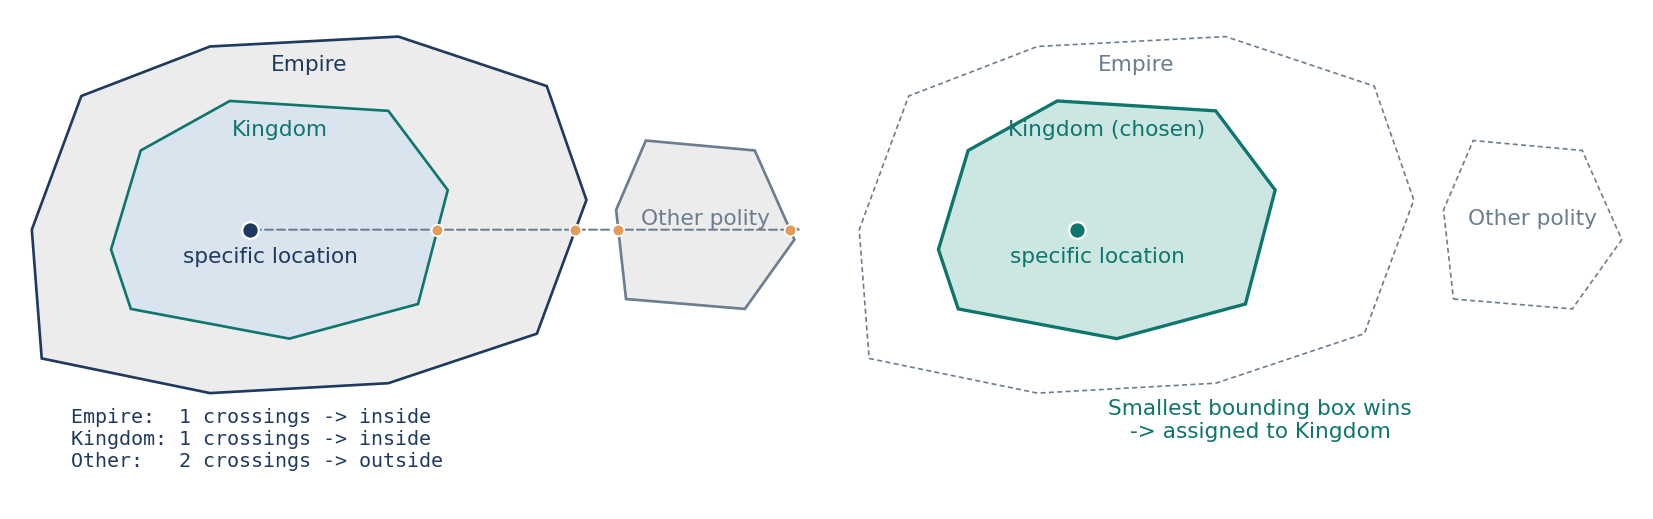

In [10]:
EMPIRE_POLYGON = [(-0.4, 0.4), (3.0, -0.3), (6.6, -0.1), (9.6, 0.9), (10.6, 3.6),
                  (9.8, 5.9), (6.8, 6.9), (3.0, 6.7), (0.4, 5.7), (-0.6, 3.0)]
KINGDOM_POLYGON = [(1.4, 1.4), (4.6, 0.8), (7.2, 1.5), (7.8, 3.8), (6.6, 5.4), (3.4, 5.6), (1.6, 4.6), (1.0, 2.6)]
OTHER_POLYGON = [(11.4, 1.6), (13.8, 1.4), (14.8, 2.8), (14.0, 4.6), (11.8, 4.8), (11.2, 3.4)]
TEST_POINT = (3.8, 3.0)
RAY_X_MAX = 15.2


def edge_crossings(point, polygon, x_max):
    px, py = point
    crossings = []
    for (x1, y1), (x2, y2) in zip(polygon, polygon[1:] + polygon[:1]):
        if (y1 > py) != (y2 > py):
            x = x1 + (py - y1) * (x2 - x1) / (y2 - y1)
            if px < x <= x_max:
                crossings.append((x, py))
    return crossings


def draw_polygon(ax, coords, face, edge, label, label_xy, lw=1.6, ls='-'):
    ax.add_patch(Polygon(coords, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, linestyle=ls))
    ax.text(*label_xy, label, fontsize=SCHEMATIC_FONTSIZE, color=edge, ha='center')


def draw_point(ax, color):
    ax.plot(*TEST_POINT, 'o', color=color, markersize=10, markeredgecolor=BACKGROUND_COLOR, markeredgewidth=1.4, zorder=5)
    ax.annotate('specific location', TEST_POINT, xytext=(-40, -20), textcoords='offset points', fontsize=SCHEMATIC_FONTSIZE, color=color)


fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
draw_polygon(ax, EMPIRE_POLYGON, SCHEMATIC_COLORS['fill'], SCHEMATIC_COLORS['primary'], 'Empire', (5.0, 6.2))
draw_polygon(ax, KINGDOM_POLYGON, SCHEMATIC_COLORS['inner_fill'], SCHEMATIC_COLORS['chosen'], 'Kingdom', (4.4, 4.9))
draw_polygon(ax, OTHER_POLYGON, SCHEMATIC_COLORS['fill'], SCHEMATIC_COLORS['neutral'], 'Other polity', (13.0, 3.1))
ax.add_patch(FancyArrowPatch(TEST_POINT, (RAY_X_MAX - 0.2, TEST_POINT[1]), arrowstyle='->', mutation_scale=12,
                             color=SCHEMATIC_COLORS['neutral'], linewidth=1.2, linestyle=(0, (4, 2))))
crossings = {name: edge_crossings(TEST_POINT, poly, RAY_X_MAX)
             for name, poly in [('Empire', EMPIRE_POLYGON), ('Kingdom', KINGDOM_POLYGON), ('Other', OTHER_POLYGON)]}
for cx, cy in sum(crossings.values(), []):
    ax.plot(cx, cy, 'o', color=SCHEMATIC_COLORS['crossing'], markersize=7, markeredgecolor=BACKGROUND_COLOR, zorder=4)
draw_point(ax, SCHEMATIC_COLORS['primary'])
ax.text(0.2, -0.6, '\n'.join(f'{name + ":":8s} {len(c)} crossings -> {"inside" if len(c) % 2 else "outside"}'
                             for name, c in crossings.items()),
        fontsize=VALUE_LABEL_FONTSIZE, color=SCHEMATIC_COLORS['primary'], family='monospace', va='top')

ax = axes[1]
draw_polygon(ax, EMPIRE_POLYGON, BACKGROUND_COLOR, SCHEMATIC_COLORS['neutral'], 'Empire', (5.0, 6.2), lw=1.0, ls=(0, (3, 2)))
draw_polygon(ax, KINGDOM_POLYGON, SCHEMATIC_COLORS['chosen_fill'], SCHEMATIC_COLORS['chosen'], 'Kingdom (chosen)', (4.4, 4.9), lw=2.0)
draw_polygon(ax, OTHER_POLYGON, BACKGROUND_COLOR, SCHEMATIC_COLORS['neutral'], 'Other polity', (13.0, 3.1), lw=1.0, ls=(0, (3, 2)))
draw_point(ax, SCHEMATIC_COLORS['chosen'])
ax.text(7.5, -1.2, 'Smallest bounding box wins\n-> assigned to Kingdom', fontsize=SCHEMATIC_FONTSIZE, color=SCHEMATIC_COLORS['chosen'], ha='center')

for ax in axes:
    ax.set_xlim(-1.0, RAY_X_MAX); ax.set_ylim(-2.6, 7.4); ax.set_aspect('equal'); ax.axis('off')
fig.tight_layout()
plt.show()

### Active individuals per polity

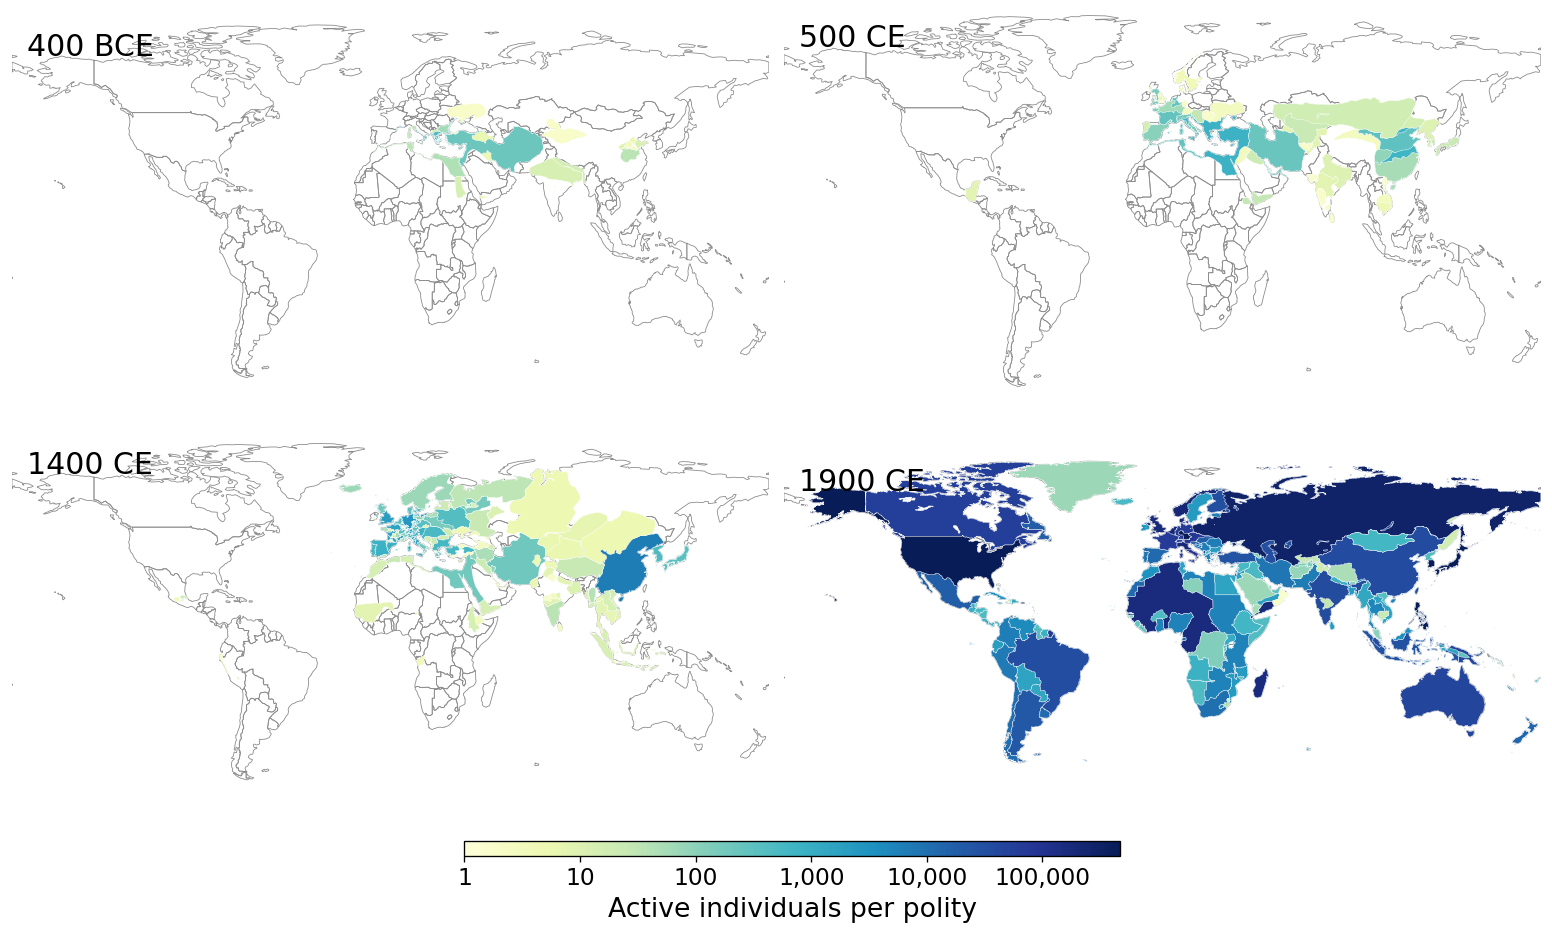

In [11]:
render_century_maps('n_all', 'Active individuals per polity')